In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2026-07-04 08:28:49.793866: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-04 08:28:49.833277: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-04 08:28:54.074554: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [3]:
datasetPath = 'dataset/firstorder/kernel5-radius5/dataset.csv'

In [4]:
# Parameters
datasetPath = "dataset/glcm/kernel5-radius5/300.dataset.csv"


In [5]:
# train/validation/test = 70/10/20
dataset = pd.read_csv(datasetPath)

train_data, temp_data = train_test_split(dataset, test_size=0.3, random_state=42)
validation_data, test_data = train_test_split(temp_data, test_size=2/3, random_state=42)

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

2026-07-04 08:29:08.198592: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-04 08:29:08.200468: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
import keras

In [8]:
%%time

# Train a Random Forest model.
model = tfdf.keras.RandomForestModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmpj5i4ke0m as temporary training directory


Reading training dataset...


Training dataset read in 0:00:03.942953. Found 235478 examples.


Training model...


[INFO 26-07-04 08:29:39.4097 UTC kernel.cc:1233] Loading model from path /tmp/tmpj5i4ke0m/model/ with prefix 464fbe0494284209


[INFO 26-07-04 08:29:40.9095 UTC decision_forest.cc:734] Model loaded with 300 root(s), 1195728 node(s), and 24 input feature(s).
[INFO 26-07-04 08:29:40.9095 UTC abstract_model.cc:1362] Engine "RandomForestOptPred" built
[INFO 26-07-04 08:29:40.9096 UTC kernel.cc:1061] Use fast generic engine


Model trained in 0:00:28.757431


Compiling model...


Model compiled.


CPU times: user 5min 12s, sys: 1.88 s, total: 5min 14s
Wall time: 35.9 s


In [9]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

 1/34 [..............................] - ETA: 1:37 - loss: 0.0000e+00 - accuracy: 0.9400

 3/34 [=>............................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9523  

 5/34 [===>..........................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9558

 7/34 [=====>........................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9554

 9/34 [======>.......................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9554

...

29/34 [========================>.....] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9558

31/34 [==========================>...] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9557

33/34 [============================>.] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9551

34/34 [==============================] - 4s 29ms/step - loss: 0.0000e+00 - accuracy: 0.9554



loss: 0.0000
accuracy: 0.9554


In [10]:
# Model Summary
model.summary()

Model: "random_forest_model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


Total params: 1 (1.00 Byte)


Trainable params: 0 (0.00 Byte)


Non-trainable params: 1 (1.00 Byte)


_________________________________________________________________


Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (24):
	Autocorrelation
	ClusterProminence
	ClusterShade
	ClusterTendency
	Contrast
	Correlation
	DifferenceAverage
	DifferenceEntropy
	DifferenceVariance
	Id
	Idm
	Idmn
	Idn
	Imc1
	Imc2
	InverseVariance
	JointAverage
	JointEnergy
	JointEntropy
	MCC
	MaximumProbability
	SumAverage
	SumEntropy
	SumSquares

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "Autocorrelation"  0.170261 ################
    2.         "SumAverage"  0.151130 ############
    3.       "JointAverage"  0.149737 ############
    4.        "Correlation"  0.140942 ###########
    5.                "MCC"  0.105133 ####
    6. "DifferenceVariance"  0.102420 ####
    7.               "Imc1"  0.101125 ####
    8.                "Idn"  0.100047 ####
    9.               "Idmn"  0.093092 ##
   10.               "Imc2"  0.091355 ##
   11.           "Contrast"  0.089893 ##
   12.    "InverseVariance"  0.087803 ##
   13.      

In [11]:
# Model features
model.make_inspector().features()

["Autocorrelation" (1; #0),
 "ClusterProminence" (1; #1),
 "ClusterShade" (1; #2),
 "ClusterTendency" (1; #3),
 "Contrast" (1; #4),
 "Correlation" (1; #5),
 "DifferenceAverage" (1; #6),
 "DifferenceEntropy" (1; #7),
 "DifferenceVariance" (1; #8),
 "Id" (1; #9),
 "Idm" (1; #10),
 "Idmn" (1; #11),
 "Idn" (1; #12),
 "Imc1" (1; #13),
 "Imc2" (1; #14),
 "InverseVariance" (1; #15),
 "JointAverage" (1; #16),
 "JointEnergy" (1; #17),
 "JointEntropy" (1; #18),
 "MCC" (1; #19),
 "MaximumProbability" (1; #20),
 "SumAverage" (1; #21),
 "SumEntropy" (1; #22),
 "SumSquares" (1; #23)]

In [12]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("Autocorrelation" (1; #0), 0.17026099058096594),
  ("SumAverage" (1; #21), 0.15113006801712955),
  ("JointAverage" (1; #16), 0.14973713926789875),
  ("Correlation" (1; #5), 0.14094158619856392),
  ("MCC" (1; #19), 0.10513319771297593),
  ("DifferenceVariance" (1; #8), 0.10241957807758105),
  ("Imc1" (1; #13), 0.10112497497687693),
  ("Idn" (1; #12), 0.10004713437432727),
  ("Idmn" (1; #11), 0.09309176126309324),
  ("Imc2" (1; #14), 0.09135523044374415),
  ("Contrast" (1; #4), 0.08989263963433877),
  ("InverseVariance" (1; #15), 0.08780328304001063),
  ("ClusterShade" (1; #2), 0.0874179656559859),
  ("DifferenceEntropy" (1; #7), 0.08485812887034415),
  ("DifferenceAverage" (1; #6), 0.08377737404098938),
  ("MaximumProbability" (1; #20), 0.08288815892582826),
  ("JointEnergy" (1; #17), 0.08030814780240635),
  ("SumEntropy" (1; #22), 0.08021786727442666),
  ("ClusterProminence" (1; #1), 0.07947186396346667),
  ("SumSquares" (1; #23), 0.07728298843077294),
  ("Id" 

In [13]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=235478, accuracy=0.9036945195521828, loss=0.28744487502055704, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

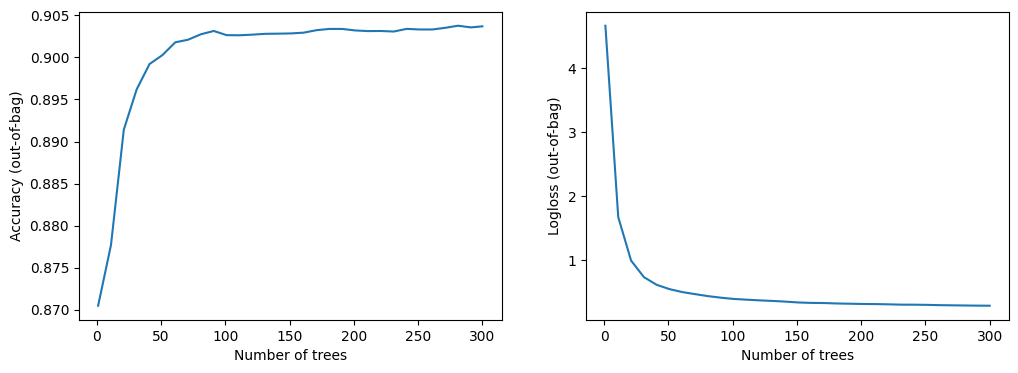

In [14]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

 1/34 [..............................] - ETA: 3s

 3/34 [=>............................] - ETA: 1s

 5/34 [===>..........................] - ETA: 0s

 7/34 [=====>........................] - ETA: 0s

 9/34 [======>.......................] - ETA: 0s

...

29/34 [========================>.....] - ETA: 0s

31/34 [==========================>...] - ETA: 0s

33/34 [============================>.] - ETA: 0s

34/34 [==============================] - 1s 30ms/step


The ROC AUC score is 0.97649


In [16]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

 1/68 [..............................] - ETA: 6s

 3/68 [>.............................] - ETA: 1s

 5/68 [=>............................] - ETA: 1s

 7/68 [==>...........................] - ETA: 1s

 9/68 [==>...........................] - ETA: 1s

...

63/68 [==========================>...] - ETA: 0s

65/68 [===========================>..] - ETA: 0s

67/68 [============================>.] - ETA: 0s

68/68 [==============================] - 2s 29ms/step


Sklearn binary metrics:
accuracy: 0.9542
precision: 0.5824
recall: 0.8485
f1: 0.6907
mcc: 0.6807
roc_auc: 0.9764
pr_auc: 0.7912
log_loss: 0.1212
brier_score: 0.0344

Confusion matrix:
 [[60752  2469]
 [  615  3444]]

Classification report:
               precision    recall  f1-score   support

           0     0.9900    0.9609    0.9752     63221
           1     0.5824    0.8485    0.6907      4059

    accuracy                         0.9542     67280
   macro avg     0.7862    0.9047    0.8330     67280
weighted avg     0.9654    0.9542    0.9581     67280

